In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/crop_dataset.csv')

In [3]:
print(df.head())

     N    P    K  temperature   humidity        ph    rainfall      label
0    7  144  197    23.849401  94.348150  6.133221  114.051249      apple
1   42   25   38    24.684050  30.442382  7.662854   93.871731      jowar
2   80   28   45    31.446877  31.094701  6.545759   72.509749      jowar
3  107   71   55    29.420179  83.967545  6.088064  117.229079     banana
4   50   55   16    28.814607  65.335381  7.581443   62.262425  blackgram


In [4]:
print(df.shape)

(5000, 8)


In [5]:
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [6]:
print(df.duplicated().sum())

0


In [7]:
df = df.drop_duplicates()

In [8]:
# Features and Target
X = df.drop('label', axis=1)
y = df['label']

In [9]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import InconsistentVersionWarning
import warnings

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'C': np.logspace(-4, 4, 50),
    'solver': ['lbfgs', 'saga'],
    'max_iter': [5000],
    'multi_class': ['multinomial']
}

lr = LogisticRegression(random_state=42)

random_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

best_lr = random_search.best_estimator_

y_pred = best_lr.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\sai\anaconda3\ANACONDA\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Parameters:
{'solver': 'saga', 'multi_class': 'multinomial', 'max_iter': 5000, 'C': np.float64(494.1713361323828)}

Best Cross Validation Accuracy:
0.79475

Test Accuracy:
0.766

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        22
       bajra       0.80      0.95      0.87        43
      banana       0.69      0.73      0.71        70
   blackgram       0.91      1.00      0.95        20
    cardamom       0.61      0.48      0.53        48
    chickpea       1.00      1.00      1.00        18
     coconut       0.71      0.81      0.76        62
      coffee       0.55      0.53      0.54        58
      cotton       0.76      0.80      0.78        56
      grapes       1.00      1.00      1.00        27
   groundnut       0.85      0.74      0.79        39
       jowar       0.71      0.63      0.67        46
        jute       0.60      0.82      0.69        11
 kidneybeans       1.00      1.00   

In [34]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

In [35]:
# Train Model
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [36]:
# Predictions
lr_pred = lr.predict(X_test_scaled)

In [37]:
# Accuracy
from sklearn.metrics import accuracy_score
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.761


In [38]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        22
       bajra       0.79      0.98      0.88        43
      banana       0.69      0.77      0.73        70
   blackgram       0.90      0.95      0.93        20
    cardamom       0.59      0.46      0.52        48
    chickpea       1.00      1.00      1.00        18
     coconut       0.72      0.85      0.78        62
      coffee       0.53      0.53      0.53        58
      cotton       0.69      0.80      0.74        56
      grapes       1.00      1.00      1.00        27
   groundnut       0.81      0.77      0.79        39
       jowar       0.72      0.63      0.67        46
        jute       0.50      0.73      0.59        11
 kidneybeans       1.00      1.00      1.00        23
      lentil       0.81      1.00      0.89        17
       maize       0.87      0.87      0.87        15
       mango       0.95      0.91      0.93        23
   mothbeans       1.00    

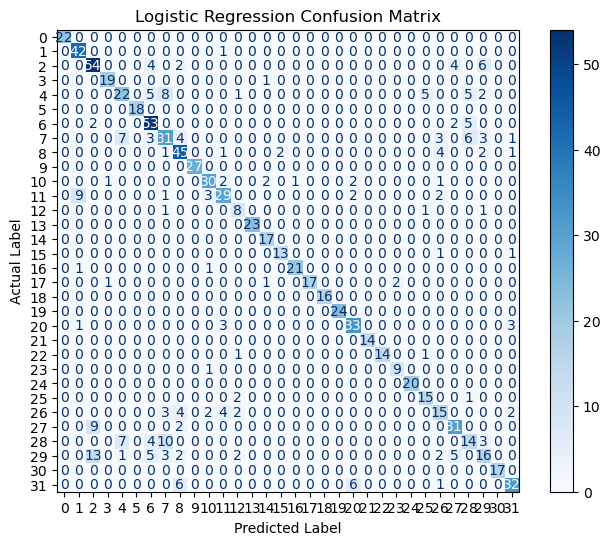

In [39]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(
    cmap='Blues',
    ax=ax,
    colorbar=True
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()